# Data5441 - Networks and High-dimensional Inference 
Semester 2, 2026

# Tutorial Week 2


In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

# 1. Generating networks


Last week we learned how to read networks from data. Let us read some more networks of interest:


In [18]:
# Read some networks from data
Gs=nx.read_adjlist("./data/edge-list-test.txt",nodetype=int) # Test
Gk=nx.read_adjlist("./data/karate_edges_77.txt",nodetype=int) # Karate Club
Gc=nx.read_adjlist("./data/celegans_edgelist.txt",nodetype=int) # C elegans
Gb=nx.read_adjlist("./data/out.moreno_blogs_blogs",nodetype=int, create_using=nx.DiGraph()) # Political Blogs
Ge = nx.read_edgelist("./data/out.arenas-email",nodetype=int,create_using=nx.DiGraph())

nameNetworks=["Simple","Karate Club","C-elegans","Blogs links","Email Exchange"]
listNetworks=[Gs,Gk,Gc,Gb,Ge]

There are other ways of generating networks:


## 1.1. Adding nodes and links
    - Start with an empty graph


In [19]:
Gconstructed=nx.empty_graph()

    - Add nodes and links.


In [20]:
Gconstructed.add_node(1)
Gconstructed.add_node(2)
Gconstructed.add_node(3)
Gconstructed.add_node(4)

In [21]:
Gconstructed.add_edge(1,2)
Gconstructed.add_edge(1,3)
Gconstructed.add_edge(1,4)
Gconstructed.add_edge(2,3)
Gconstructed.add_edge(2,4)

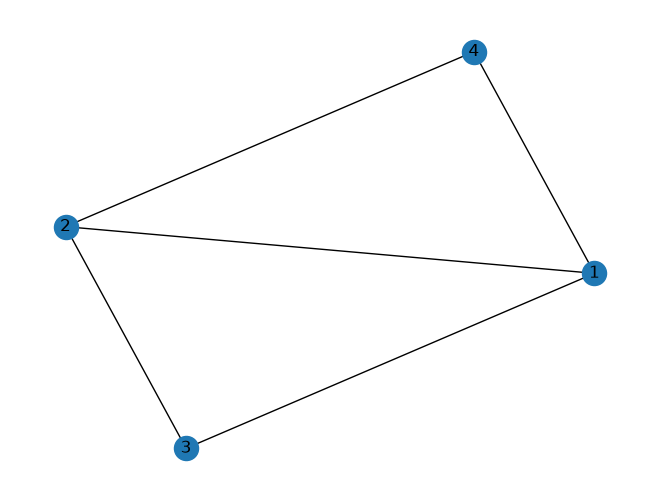

In [22]:
nx.draw(Gconstructed,with_labels=True)

## 1.2. From a network model


    - We'll learn more about random graphs later, but here is a simple example of a random graph with 100 nodes, each node having exactly 5 links.


In [23]:
Gregular = nx.random_regular_graph(5,100,seed=1)

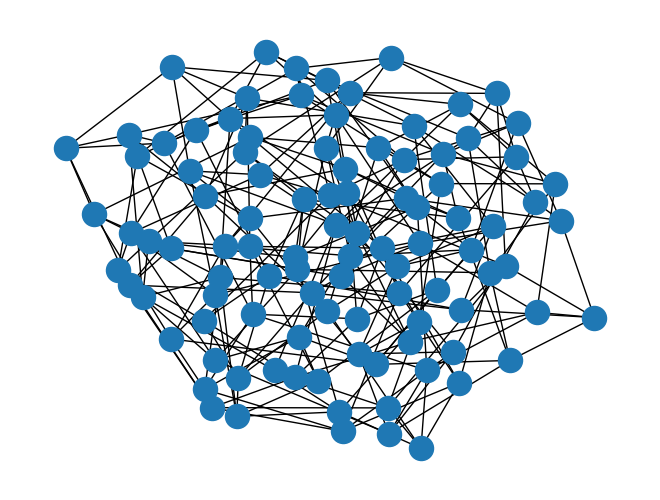

In [24]:
nx.draw(Gregular)

# 2. Centrality Measures


NetworkX provides functions for computing common centrality measures, including `nx.degree_centrality(G)`, `nx.eigenvector_centrality(G)`, `nx.katz_centrality(G)`, `nx.pagerank(G)`, and `nx.betweenness_centrality(G)`. 

- Each function returns a dictionary mapping nodes to their centrality values. Some measures require parameters: for example, Katz centrality uses an attenuation factor `alpha`, which must satisfy $\alpha < 1/\lambda_{\max}$, where $\lambda_{\max}$ is the largest eigenvalue of the adjacency matrix. Here we use $\alpha=0.01$. 
- For directed graphs, eigenvector, Katz, and PageRank centralities measure importance primarily through incoming links; use `G.reverse()` when influence through outgoing links is intended. 
- Results can be ranked using `sorted(centrality.items(), key=lambda item: item[1], reverse=True)`.

The function below prints the top nodes according to each centrality.

In [25]:
# Centrality measures

measuresNames=["Degree","Eigenvector","Katz","Page Rank","Betweenness"]

def print_top_centralities(G):
    listMeasures = [dict(nx.degree(G)),nx.eigenvector_centrality(G,max_iter=1000),nx.katz_centrality_numpy(G,alpha=0.01),nx.pagerank(G),nx.betweenness_centrality(G)]

    for idx,dictMeasure in enumerate(listMeasures):
        top10 = [[dictMeasure[k],k] for k in dictMeasure.keys()] # Choose the 10 largest values
        top10.sort(reverse=True)
        print("\n Centrality Measure:",measuresNames[idx])
        for rank,pair in enumerate(top10[:10]):
            print(str(rank+1),": \t is node ",pair[1]," with value:\t",pair[0])

print_top_centralities(Gk)


 Centrality Measure: Degree
1 : 	 is node  34  with value:	 16
2 : 	 is node  1  with value:	 16
3 : 	 is node  33  with value:	 12
4 : 	 is node  3  with value:	 10
5 : 	 is node  2  with value:	 9
6 : 	 is node  32  with value:	 6
7 : 	 is node  4  with value:	 6
8 : 	 is node  24  with value:	 5
9 : 	 is node  14  with value:	 5
10 : 	 is node  9  with value:	 5

 Centrality Measure: Eigenvector
1 : 	 is node  1  with value:	 0.3687259609561096
2 : 	 is node  34  with value:	 0.3564323310963734
3 : 	 is node  3  with value:	 0.3243678114012024
4 : 	 is node  33  with value:	 0.29769755751183175
5 : 	 is node  2  with value:	 0.27560854485524394
6 : 	 is node  14  with value:	 0.23152343277913826
7 : 	 is node  9  with value:	 0.22789782008485054
8 : 	 is node  4  with value:	 0.21977594506278408
9 : 	 is node  32  with value:	 0.19027268463495867
10 : 	 is node  8  with value:	 0.1781071732757733

 Centrality Measure: Katz
1 : 	 is node  1  with value:	 0.19074976601029972
2 : 	 is

## Exercise 2.1. Centrality measures of simple examples

- Starting from an empty graph, construct the two simple examples discussed in class (a star graph and a simple 3x3 lattice)



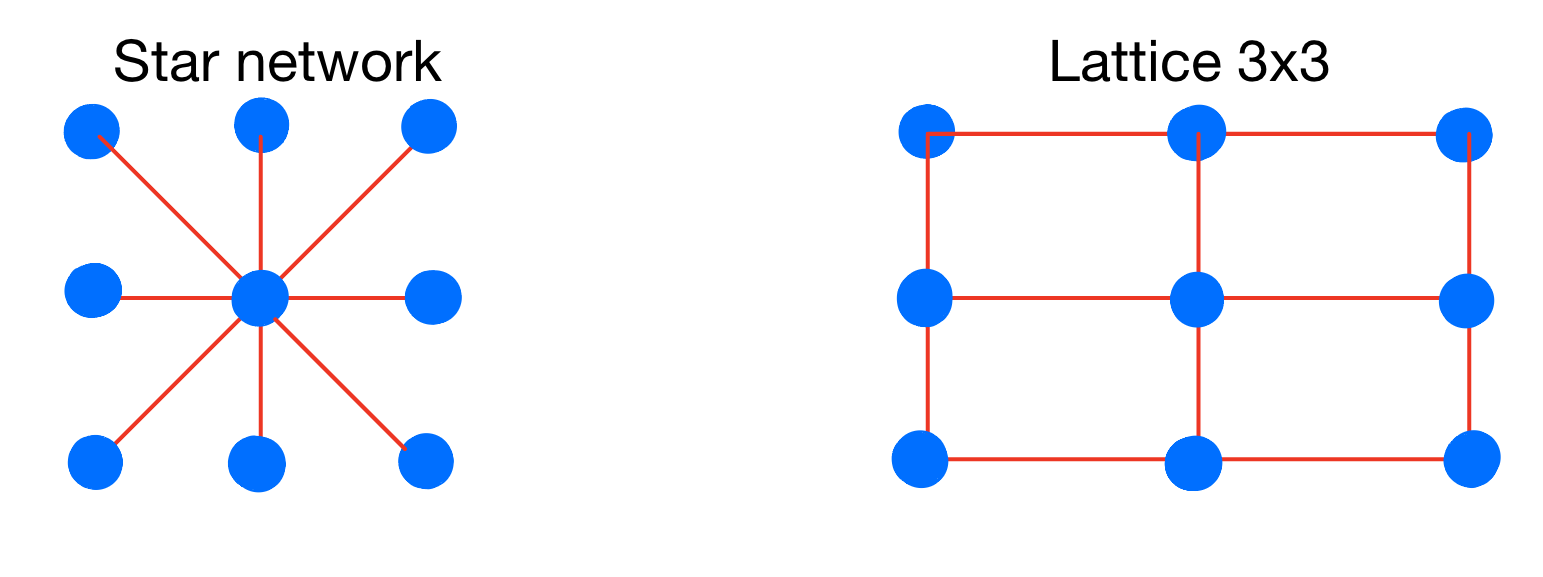

In [26]:
from IPython.display import Image, display
display(Image("draw2.png",width=800))

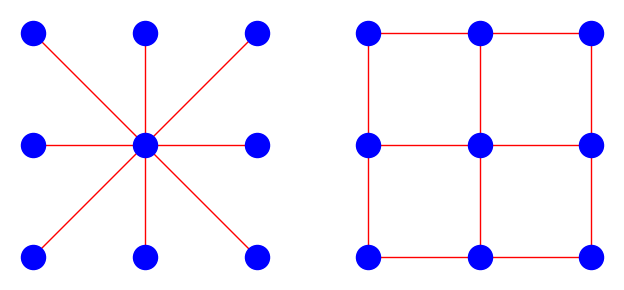

In [27]:
A = np.zeros((9, 9))
A[4, :] = 1
A[:, 4] = 1
A[4, 4] = 0

P = np.diag(np.ones(2), 1) + np.diag(np.ones(2), -1)
B = np.kron(P, np.eye(3)) + np.kron(np.eye(3), P)
B = B.astype(int)

G1 = nx.Graph(A)
G2 = nx.Graph(B)

pos = {i: (i % 3, -(i // 3)) for i in range(9)}

fig, ax = plt.subplots(1, 2, figsize=(7, 3))

nx.draw_networkx(G1, pos=pos, ax=ax[0], with_labels=False, node_size=300, edge_color="red", node_color="blue")
ax[0].axis("off")
ax[0].set_aspect("equal")

nx.draw_networkx(G2, pos=pos, ax=ax[1], with_labels=False, node_size=300, edge_color="red", node_color="blue")
ax[1].axis("off")
ax[1].set_aspect("equal")

plt.tight_layout()
plt.show()

In [28]:
print_top_centralities(G1)
print("-----------------------------")
print_top_centralities(G2)


 Centrality Measure: Degree
1 : 	 is node  4  with value:	 8
2 : 	 is node  8  with value:	 1
3 : 	 is node  7  with value:	 1
4 : 	 is node  6  with value:	 1
5 : 	 is node  5  with value:	 1
6 : 	 is node  3  with value:	 1
7 : 	 is node  2  with value:	 1
8 : 	 is node  1  with value:	 1
9 : 	 is node  0  with value:	 1

 Centrality Measure: Eigenvector
1 : 	 is node  4  with value:	 0.7071062168043301
2 : 	 is node  8  with value:	 0.2500001995390873
3 : 	 is node  7  with value:	 0.2500001995390873
4 : 	 is node  6  with value:	 0.2500001995390873
5 : 	 is node  5  with value:	 0.2500001995390873
6 : 	 is node  3  with value:	 0.2500001995390873
7 : 	 is node  2  with value:	 0.2500001995390873
8 : 	 is node  1  with value:	 0.2500001995390873
9 : 	 is node  0  with value:	 0.2500001995390873

 Centrality Measure: Katz
1 : 	 is node  4  with value:	 0.35362919372670915
2 : 	 is node  3  with value:	 0.33070878302220025
3 : 	 is node  2  with value:	 0.33070878302220025
4 : 	 is n

- Compute the centrality measures for these graphs and consider whether they correspond to your expectations.


In [29]:
print_top_centralities(G1)
print("----------------------")
print_top_centralities(G2)


 Centrality Measure: Degree
1 : 	 is node  4  with value:	 8
2 : 	 is node  8  with value:	 1
3 : 	 is node  7  with value:	 1
4 : 	 is node  6  with value:	 1
5 : 	 is node  5  with value:	 1
6 : 	 is node  3  with value:	 1
7 : 	 is node  2  with value:	 1
8 : 	 is node  1  with value:	 1
9 : 	 is node  0  with value:	 1

 Centrality Measure: Eigenvector
1 : 	 is node  4  with value:	 0.7071062168043301
2 : 	 is node  8  with value:	 0.2500001995390873
3 : 	 is node  7  with value:	 0.2500001995390873
4 : 	 is node  6  with value:	 0.2500001995390873
5 : 	 is node  5  with value:	 0.2500001995390873
6 : 	 is node  3  with value:	 0.2500001995390873
7 : 	 is node  2  with value:	 0.2500001995390873
8 : 	 is node  1  with value:	 0.2500001995390873
9 : 	 is node  0  with value:	 0.2500001995390873

 Centrality Measure: Katz
1 : 	 is node  4  with value:	 0.35362919372670915
2 : 	 is node  3  with value:	 0.33070878302220025
3 : 	 is node  2  with value:	 0.33070878302220025
4 : 	 is n

## Exercise 2.2. Directed graph


Let $G_d$ be the **directed** graph depicted below. In this graph, 20 nodes link to a focal node (node 0). The focal node links to a single other node (node 21) that links to and from one more node (node 22). 

a) Without making any computation, which nodes do you expect to be the most central nodes according to the different centrality measures considered so far?

b) Write Python code that generates this network and computes the centrality measures. Discuss whether the results match your expectations and clarify any potential divergence.

Hint: You need to create a directed graph, not a simple graph. To learn how to do so in NetworkX, use the "help()" command, the [NetworkX tutorial](https://networkx.org/documentation/stable/tutorial.html), or ask [Copilot](https://copilot.microsoft.com/) (log-in with your Uni account).


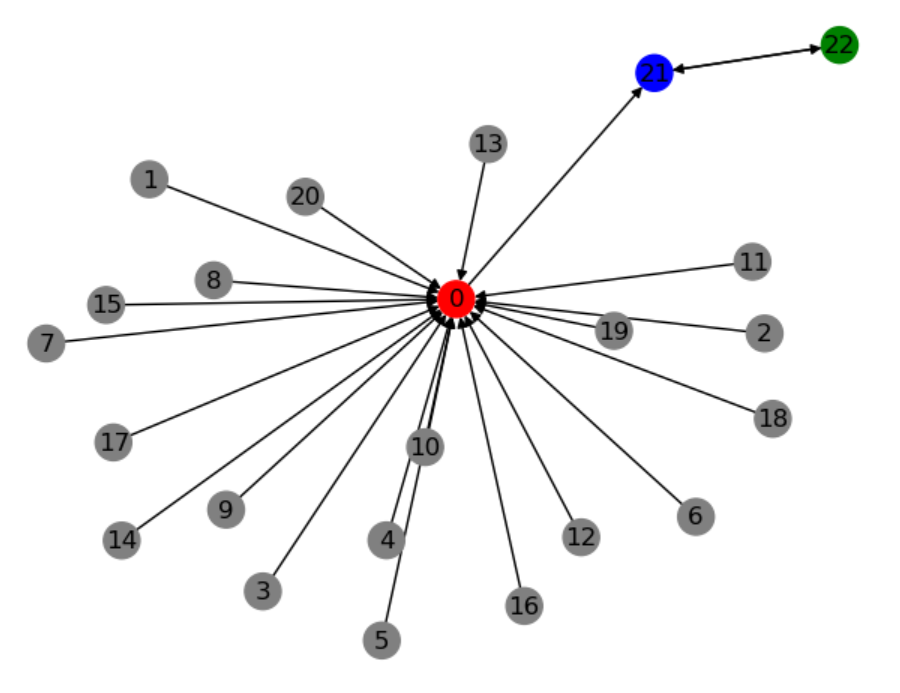

In [30]:
display(Image("netDirected.png",width=800))

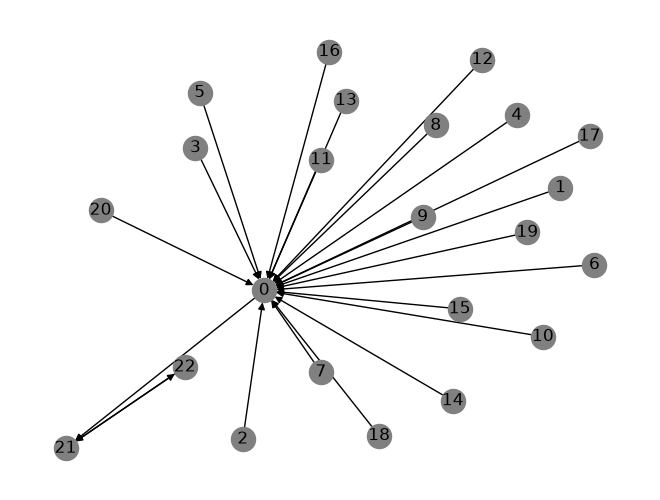

In [31]:
adj_mat = np.zeros((23,23))
adj_mat[:, 0] = 1
adj_mat[0, 0] = 0
adj_mat[21, 0] = 0
adj_mat[0, 21] = 1

adj_mat[22, 0] = 0

adj_mat[21, 22] = 1
adj_mat[22, 21] = 1


G_directed = nx.DiGraph(adj_mat)
pos = nx.spring_layout(G_directed, seed=42, method="force")

plt.Figure(figsize=(6, 6))
nx.draw(G_directed, pos=pos, with_labels=True, node_size=300, edge_color="black", node_color="grey")

In [32]:
print_top_centralities(G_directed)


 Centrality Measure: Degree
1 : 	 is node  0  with value:	 21
2 : 	 is node  21  with value:	 3
3 : 	 is node  22  with value:	 2
4 : 	 is node  20  with value:	 1
5 : 	 is node  19  with value:	 1
6 : 	 is node  18  with value:	 1
7 : 	 is node  17  with value:	 1
8 : 	 is node  16  with value:	 1
9 : 	 is node  15  with value:	 1
10 : 	 is node  14  with value:	 1

 Centrality Measure: Eigenvector
1 : 	 is node  21  with value:	 0.7071126597311138
2 : 	 is node  22  with value:	 0.7071009024853577
3 : 	 is node  0  with value:	 1.2343642053174561e-05
4 : 	 is node  20  with value:	 2.931981485314624e-08
5 : 	 is node  19  with value:	 2.931981485314624e-08
6 : 	 is node  18  with value:	 2.931981485314624e-08
7 : 	 is node  17  with value:	 2.931981485314624e-08
8 : 	 is node  16  with value:	 2.931981485314624e-08
9 : 	 is node  15  with value:	 2.931981485314624e-08
10 : 	 is node  14  with value:	 2.931981485314624e-08

 Centrality Measure: Katz
1 : 	 is node  0  with value:	 0.2

## Exercise 2.3. What is the most central character in your favourite fiction world?

Possible choices:

 - Characters from *Les Miserables*, the novel by Victor Hugo. Load the network with `G = nx.read_gml("data/lesmiserables.gml")`; see also
https://github.com/gephi/gephi/wiki/Datasets
- Characters from Marvel Comics: https://networks.skewed.de/net/marvel_universe       (19,428 nodes) https://networks.skewed.de/net/marvel_partnerships  (318 nodes)
- Network of Star Wars (movie) characters: https://github.com/evelinag/StarWars-social-network/blob/master/networks/README.md


Compute different centrality measures to identify the most central characters.


### Les Miserables

In [33]:
G = nx.read_gml("data/lesmiserables.gml")
print_top_centralities(G)


 Centrality Measure: Degree
1 : 	 is node  Valjean  with value:	 36
2 : 	 is node  Gavroche  with value:	 22
3 : 	 is node  Marius  with value:	 19
4 : 	 is node  Javert  with value:	 17
5 : 	 is node  Thenardier  with value:	 16
6 : 	 is node  Fantine  with value:	 15
7 : 	 is node  Enjolras  with value:	 15
8 : 	 is node  Courfeyrac  with value:	 13
9 : 	 is node  Bossuet  with value:	 13
10 : 	 is node  Joly  with value:	 12

 Centrality Measure: Eigenvector
1 : 	 is node  Gavroche  with value:	 0.3178389397749768
2 : 	 is node  Valjean  with value:	 0.2676181759885394
3 : 	 is node  Enjolras  with value:	 0.2671786328235667
4 : 	 is node  Marius  with value:	 0.25911114534178753
5 : 	 is node  Bossuet  with value:	 0.24213078637474136
6 : 	 is node  Courfeyrac  with value:	 0.23246719717021408
7 : 	 is node  Joly  with value:	 0.22155360926119969
8 : 	 is node  Bahorel  with value:	 0.22155360926119969
9 : 	 is node  Feuilly  with value:	 0.21073457488115618
10 : 	 is node  Combef

### Star Wars

In [18]:
import json

with open("data/starwars-full-mentions.json", "r") as f:
    data = json.load(f)

nodes_df = pd.DataFrame(data["nodes"])
links_df = pd.DataFrame(data["links"])

name_map = nodes_df["name"].to_dict()

links_df["source"] = links_df["source"].map(name_map)
links_df["target"] = links_df["target"].map(name_map)

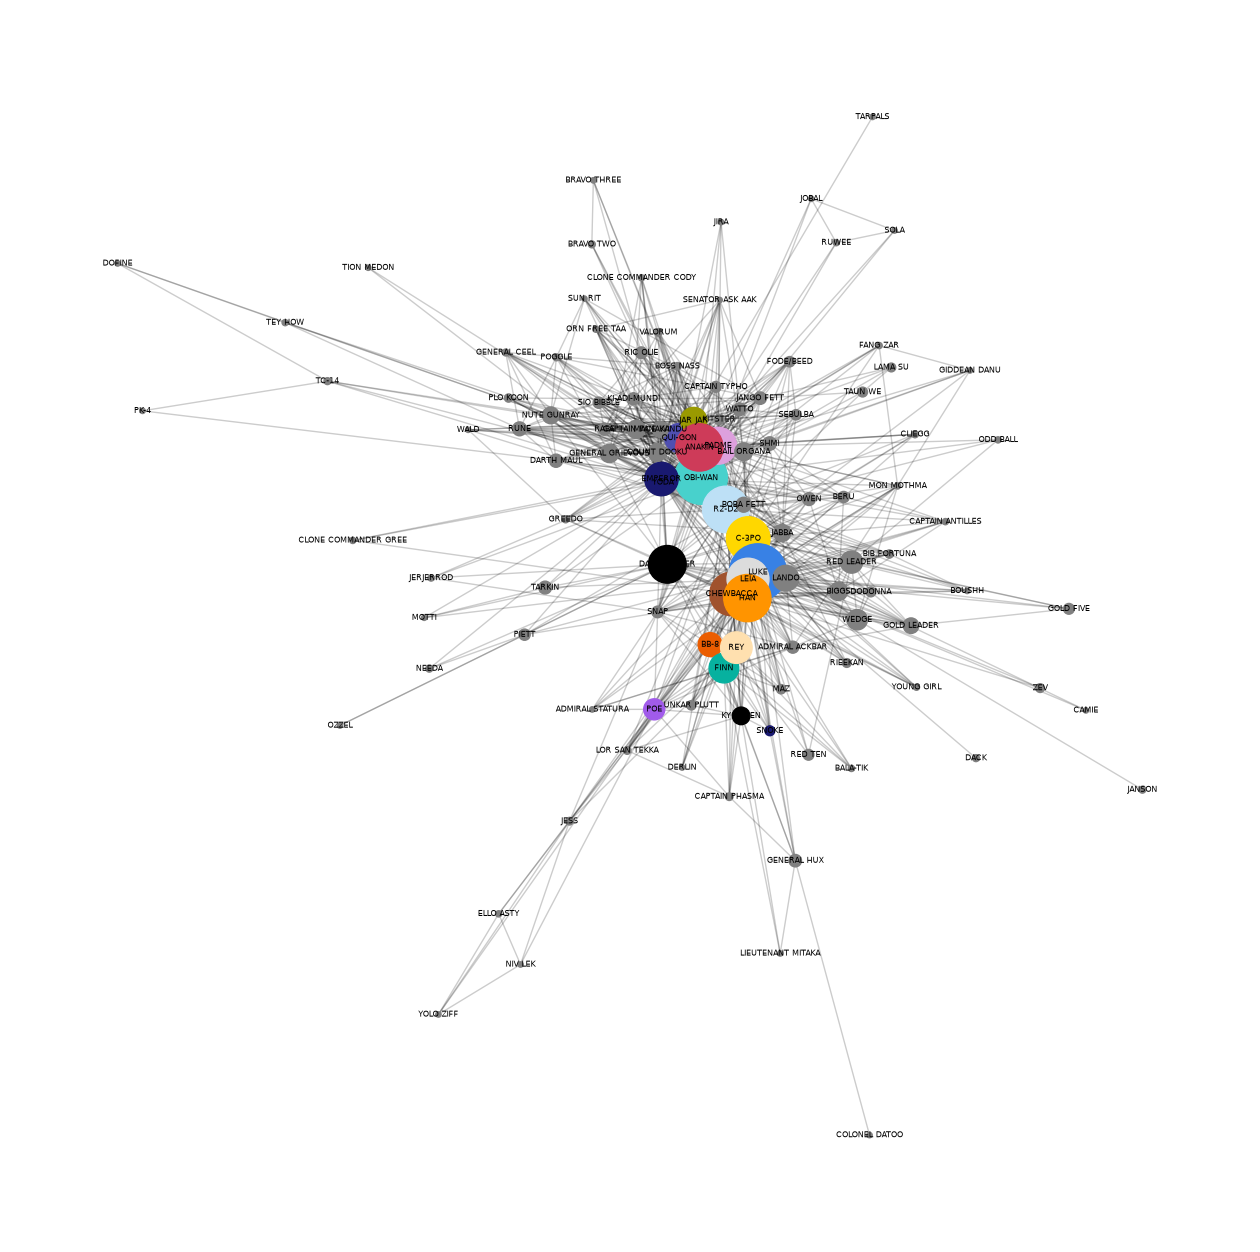

In [19]:
G = nx.Graph()

for _, row in nodes_df.iterrows():
    G.add_node(row["name"], value=row["value"], colour=row["colour"])

for _, row in links_df.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["value"])

pos = nx.spring_layout(G, seed=42)
node_sizes = [G.nodes[node]["value"] * 5 for node in G.nodes]
node_colours = [G.nodes[node]["colour"] for node in G.nodes]


plt.figure(figsize=(16, 16))

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colours)
nx.draw_networkx_edges(G, pos, alpha=0.2)
nx.draw_networkx_labels(G, pos, font_size=6)

plt.axis("off")
plt.show()

In [20]:
print_top_centralities(G)


 Centrality Measure: Degree
1 : 	 is node  R2-D2  with value:	 60
2 : 	 is node  OBI-WAN  with value:	 60
3 : 	 is node  ANAKIN  with value:	 57
4 : 	 is node  C-3PO  with value:	 52
5 : 	 is node  PADME  with value:	 51
6 : 	 is node  EMPEROR  with value:	 49
7 : 	 is node  LUKE  with value:	 46
8 : 	 is node  LEIA  with value:	 44
9 : 	 is node  HAN  with value:	 41
10 : 	 is node  CHEWBACCA  with value:	 37

 Centrality Measure: Eigenvector
1 : 	 is node  R2-D2  with value:	 0.2506341932346775
2 : 	 is node  OBI-WAN  with value:	 0.24827735516637742
3 : 	 is node  ANAKIN  with value:	 0.23894031887275521
4 : 	 is node  C-3PO  with value:	 0.2242630990984937
5 : 	 is node  PADME  with value:	 0.21964036061790748
6 : 	 is node  EMPEROR  with value:	 0.21545654160422323
7 : 	 is node  YODA  with value:	 0.18852704270600573
8 : 	 is node  LEIA  with value:	 0.1818481981819356
9 : 	 is node  LUKE  with value:	 0.1815486926378877
10 : 	 is node  JAR JAR  with value:	 0.16986021100528642


# 3. Comparing networks

Here we are interested in comparing network properties introduced in Week 1 on different networks. For a fair comparison, we will consider networks with increasing numbers of nodes $N$, in which most nodes have a fixed degree $z=8$. In each case, we will focus on the following measures, which are useful to characterize local and global properties of a network:


  $z_i$ := degree of node $i$, where $i=1, 2, \ldots, N$ nodes.
  
  $C_i$ := clustering coefficient of node $i$.
  
  $C_{net}$ := the clustering coefficient of the network ($\neq  \langle C \rangle$).
  
   $\langle d_i \rangle$ := $\frac{1}{N-1} \sum_{j \ne i} d_{i,j}$, the average geodesic distance from node $i$ to all other nodes $j$.
 
 $d_{diam}$ := $\max_{i,j} d_{i,j}$, the diameter of the network ($\neq \langle \langle d \rangle \rangle := \frac{1}{N} \sum_{i=1}^N \langle d_i \rangle$).
    
$\langle \ldots \rangle$ is the average over all $N$ nodes of the network (i.e., $\langle f \rangle = \frac{1}{N} \sum_{i=1}^N f_i$).



## Exercise 3.1. Lattice clustering and distances

We start with an $M=3$ by $M=3$ network of $N=9$ nodes in the form of a lattice, as shown below. Compute (with pen and paper) the quantities listed above for this network, including the local quantities for all nodes.



C:\Users\Mani\AppData\Local\Temp\ipykernel_30716\1835676531.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


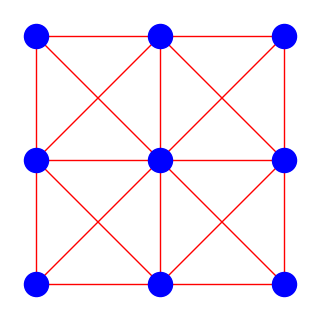

In [21]:
A = np.array([
    [0,1,0,1,1,0,0,0,0],
    [1,0,1,1,1,1,0,0,0],
    [0,1,0,0,1,1,0,0,0],
    [1,1,0,0,1,0,1,1,0],
    [1,1,1,1,0,1,1,1,1],
    [0,1,1,0,1,0,0,1,1],
    [0,0,0,1,1,0,0,1,0],
    [0,0,0,1,1,1,1,0,1],
    [0,0,0,0,1,1,0,1,0]
])

G_lattice = nx.Graph(A)

pos = {i: (i % 3, -(i // 3)) for i in range(9)}

plt.figure(figsize=(3,3))
nx.draw(G_lattice, pos=pos, with_labels=False, node_size=300, edge_color="red", node_color="blue")
ax[0].axis("off")
ax[0].set_aspect("equal")

plt.tight_layout()
plt.show()


Write code that generates an $M$ by $M$ lattice that generalizes the $M=3$ case shown above, including diagonal neighbours. Use the networks obtained through this code to test your analytical calculations and to generate **two** plots:
    
(a) One plot that shows how $\langle C \rangle$ and  $C_{net}$ depend on $M$, including a curve depicting your analytical calculations for $\langle C \rangle$. 
    
(b) One plot that shows how $\langle \langle d \rangle \rangle$ and $d_{diam}$ depend on $M$, including the lower and upper bound results obtained in your analytical calculations for $\langle \langle d \rangle \rangle$.

In [22]:
def grid_adjacency(M):
    n = M * M
    A = np.zeros((n, n))

    for row in range(M):
        for col in range(M):
            u = row * M + col

            for dr in [-1, 0, 1]:
                for dc in [-1, 0, 1]:
                    if dr == 0 and dc == 0:
                        continue

                    r = row + dr
                    c = col + dc

                    if 0 <= r < M and 0 <= c < M:
                        v = r * M + c
                        A[u, v] = 1

    return A


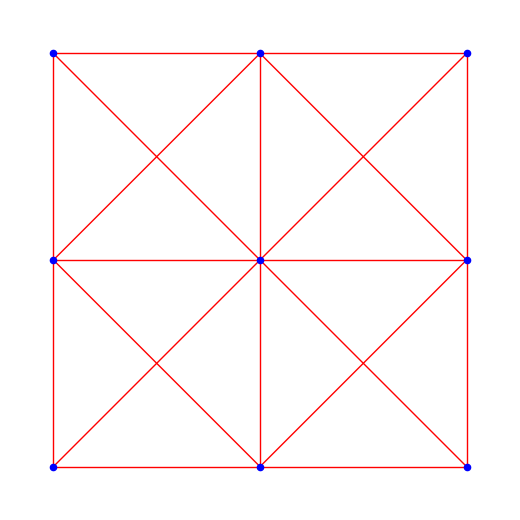

In [23]:
M=3

A = grid_adjacency(M)
G_lattice = nx.Graph(A)

pos = {i: (i % M, -(i // M)) for i in range(M**2)}

plt.figure(figsize=(5,5))
nx.draw(G_lattice, pos=pos, with_labels=False, node_size=20, edge_color="red", node_color="blue")
ax[0].axis("off")
ax[0].set_aspect("equal")

plt.show()

In [24]:
sample_size = 50
rerun = False

if rerun:
    C_net_ls = []
    C_avg_ls = []
    max_diam_ls = []
    avg_diam_ls = []

    for M in range(1, sample_size):
        A = grid_adjacency(M)
        G = nx.from_numpy_array(A)

        C_net_ls.append(nx.transitivity(G))
        C_avg_ls.append(nx.average_clustering(G))
        max_diam_ls.append(nx.diameter(G))
        avg_diam_ls.append(nx.average_shortest_path_length(G))

    data = pd.DataFrame({"C_net": C_net_ls, "C_avg": C_avg_ls, "max_diam": max_diam_ls, "avg_diam": avg_diam_ls})
    data.to_csv(f"outputs/lattice_data_sample_size_{sample_size}.csv", index=False)
else:
    data = pd.read_csv(f"outputs/lattice_data_sample_size_{sample_size}.csv")
    C_net_ls = data["C_net"].to_list()
    C_avg_ls = data["C_avg"].to_list()
    max_diam_ls = data["max_diam"].to_list()
    avg_diam_ls = data["avg_diam"].to_list()

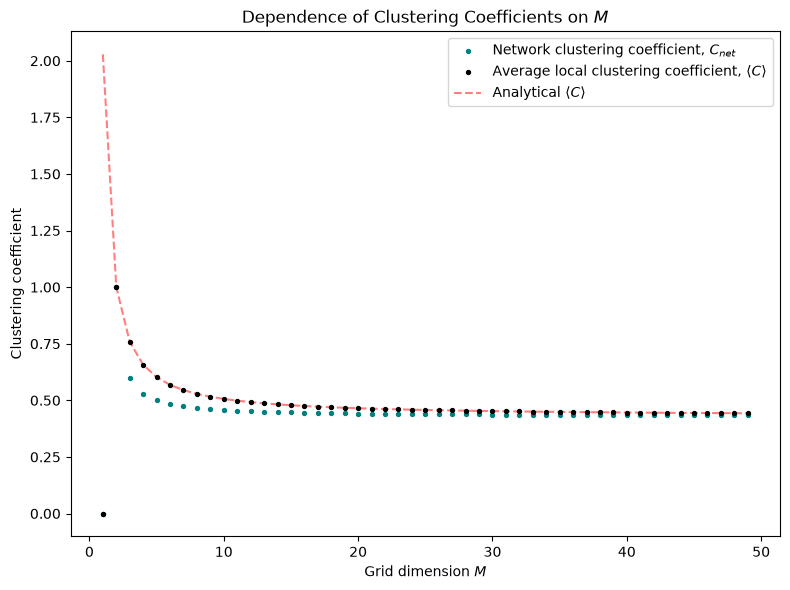

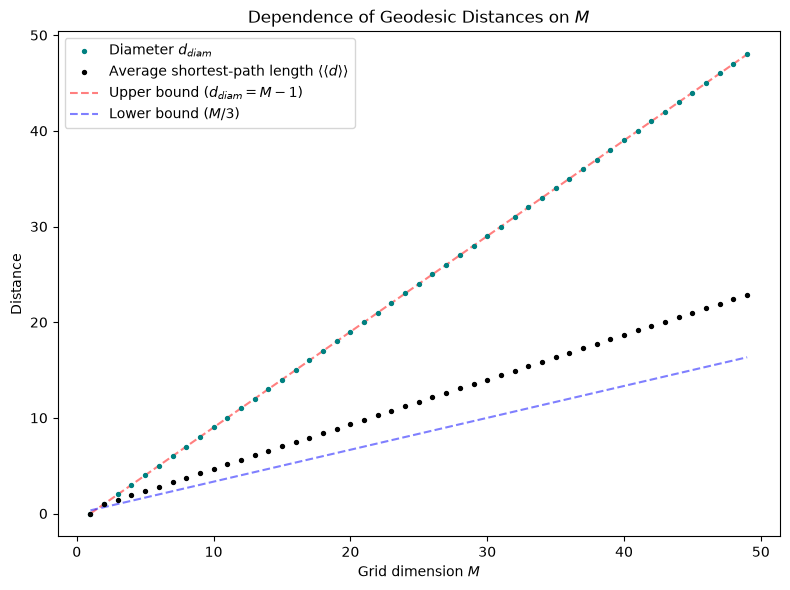

In [32]:
M_arr = np.arange(1, sample_size)
C_avg_analytical = (3/7) + (24/(35*M_arr)) + (32/(35*M_arr**2))

plt.figure(figsize=(8,6))
plt.scatter(M_arr, C_net_ls, color="teal", s=8, label="Network clustering coefficient, $C_{net}$", zorder=2)
plt.scatter(M_arr, C_avg_ls, color="black", s=8, label="Average local clustering coefficient, $\\langle C \\rangle$", zorder=2)
plt.plot(M_arr, C_avg_analytical, color="red", linestyle="--", label="Analytical $\\langle C \\rangle$", zorder=1, alpha=0.5)
plt.xlabel("Grid dimension $M$")
plt.ylabel("Clustering coefficient")
plt.legend()
plt.title("Dependence of Clustering Coefficients on $M$")
plt.tight_layout()
plt.show()


upper_bound = M_arr - 1
lower_bound = M_arr / 3

plt.figure(figsize=(8,6))
plt.scatter(M_arr, max_diam_ls, color="teal", s=8, label="Diameter $d_{diam}$", zorder=2)
plt.scatter(M_arr, avg_diam_ls, color="black", s=8, label="Average shortest-path length $\\langle\\langle d \\rangle\\rangle$", zorder=2)
plt.plot(M_arr, upper_bound, color="red", linestyle="--", label="Upper bound ($d_{diam} = M - 1$)", zorder=1, alpha=0.5)
plt.plot(M_arr, lower_bound, color="blue", linestyle="--", label="Lower bound ($M / 3$)", zorder=1, alpha=0.5)

plt.xlabel("Grid dimension $M$")
plt.ylabel("Distance")
plt.legend()
plt.title("Dependence of Geodesic Distances on $M$")
plt.tight_layout()
plt.show()

## Exercise 3.2. Random k-regular graphs

Consider networks for which all $N$ nodes have the same degree $z_i=k$ and the $L= k N/2$ links are distributed randomly. These networks are known as k-regular graphs. 
    
Compute $\langle z \rangle, \sigma_z:=\sqrt{\langle z^2 \rangle - (\langle z \rangle)^2},\langle C \rangle,  d_{diam}, \langle \langle d \rangle \rangle$ for increasingly large $N$ and consider what happens for $N\rightarrow \infty$. Some cases are trivial, but in other cases you may need to use Python to generate networks with increasing $N$ (possibly plotting how the quantities grow with $N$).


A k-regular graph with $N$ nodes and fixed degree $k$ can be generated in NetworkX as:


In [ ]:
def compute_random_graph_properties(k, N, seed=None):
    rng = np.random.default_rng(seed)

    while True:
        graph_seed = int(rng.integers(0, 2**32 - 1))
        Gk = nx.random_regular_graph(k, N, seed=graph_seed)
        if nx.is_connected(Gk):
            break

    degrees = np.array([degree for _, degree in Gk.degree()], dtype=float)
    avg_degree = np.mean(degrees)
    degree_std = np.std(degrees)
    avg_clustering = nx.transitivity(Gk)
    diameter = nx.diameter(Gk)
    avg_path_length = nx.average_shortest_path_length(Gk)

    return avg_degree, degree_std, avg_clustering, diameter, avg_path_length

In [37]:
def generate_k_regular_data(k_values, N_values, seed=42):
    np.random.seed(seed)
    results = []

    for k in k_values:
        for N in N_values:

            G = nx.random_regular_graph(k, N)
            
            avg_z = k
            sigma_z = 0 # We did this in class
            
            c_avg = nx.average_clustering(G)
            
            if nx.is_connected(G):
                avg_d = nx.average_shortest_path_length(G)
                diam = nx.diameter(G)
            else:
                largest_cc = max(nx.connected_components(G), key=len)
                G_sub = G.subgraph(largest_cc)
                avg_d = nx.average_shortest_path_length(G_sub)
                diam = nx.diameter(G_sub)
                print(f"Graph (k={k}, N={N}) was disconnected. Metrics computed on largest component.")
                
            results.append({
                'k': k,
                'N': N,
                'avg_z': avg_z,
                'sigma_z': sigma_z,
                'C_avg': c_avg,
                'avg_diam': avg_d,
                'max_diam': diam
            })
            
    return pd.DataFrame(results)

In [45]:
import matplotlib.cm as cm

k_list = [2, 4, 6, 8, 10]
N_list = [20, 40, 80, 160, 320]

df = generate_k_regular_data(k_list, N_list)

colors_C = cm.Blues(np.linspace(0.4, 1, len(k_list)))
colors_avg_d = cm.Greens(np.linspace(0.4, 1, len(k_list)))
colors_max_d = cm.Reds(np.linspace(0.4, 1, len(k_list)))

Graph (k=2, N=20) was disconnected. Metrics computed on largest component.
Graph (k=2, N=80) was disconnected. Metrics computed on largest component.
Graph (k=2, N=160) was disconnected. Metrics computed on largest component.
Graph (k=2, N=320) was disconnected. Metrics computed on largest component.


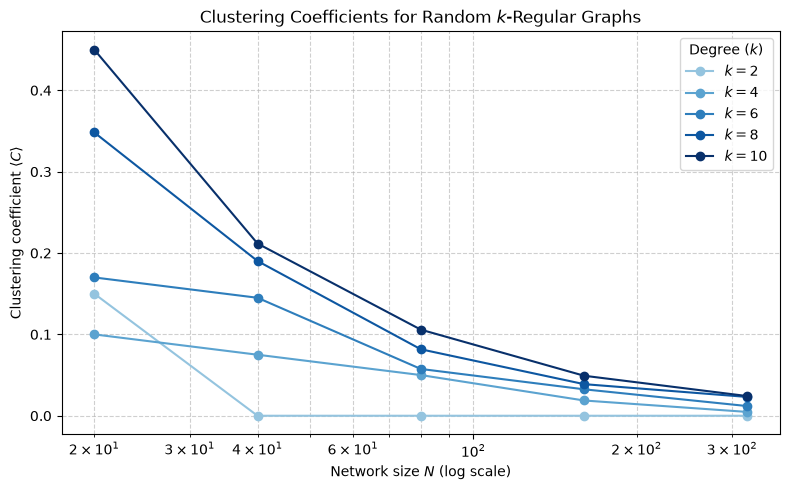

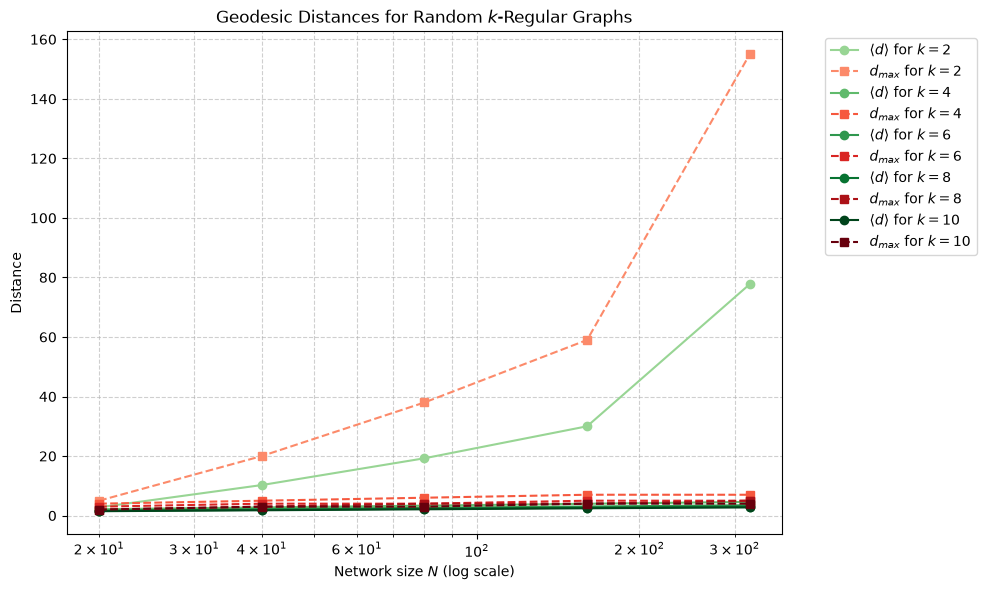

In [48]:
plt.figure(figsize=(8, 5))

for i, k in enumerate(k_list):
    df_k = df[df['k'] == k]
    
    plt.plot(df_k['N'], df_k['C_avg'], marker='o', color=colors_C[i],  label=f"$k = {k}$")

plt.xlabel("Network size $N$ (log scale)")
plt.ylabel("Clustering coefficient $\\langle C \\rangle$")
plt.title("Clustering Coefficients for Random $k$-Regular Graphs")
plt.xscale("log")
plt.legend(title="Degree ($k$)")
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))

for i, k in enumerate(k_list):
    df_k = df[df['k'] == k]
    
    plt.plot(df_k['N'], df_k['avg_diam'], marker='o', linestyle='-', color=colors_avg_d[i], label=f"$\\langle d \\rangle$ for $k = {k}$")
             
    plt.plot(df_k['N'], df_k['max_diam'], marker='s', linestyle='--', color=colors_max_d[i], label=f"$d_{{max}}$ for $k = {k}$")    

plt.xlabel("Network size $N$ (log scale)")
plt.ylabel("Distance")
plt.title("Geodesic Distances for Random $k$-Regular Graphs")
plt.xscale("log")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()